[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Evaluation and Method Comparison

**Inputs.** The newest finished run of each method and seed under `outputs/optim/`, the baseline radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.

No GPU is needed and nothing is re-traced. Every table and figure is built by `src/evaluation/run.py`, the same code
`task evaluate` runs; this notebook only presents them.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.run import evaluate

# evaluate() seeds, sets the figure defaults and saves every table and figure itself.
cfg = load_config(overrides=CONFIG_OVERRIDES)
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

Build every table and figure once. Run directories that did not finish writing are skipped with a `WARNING` line.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)

## 1. Evaluation Objective

This notebook compares search methods for **multi-band antenna tilt coordination**: one absolute tilt per cell-band
pair, chosen to

* reduce coverage holes,
* reduce co-band coverage overlap and the number of overlapping neighbours,
* reduce weak coverage,
* serve more UEs within the cells' PRB capacity,

at a reasonable number of expensive ray-tracing evaluations. The KPIs are reported side by side and weighed equally;
none is ranked above another. The single number a search maximises is the objective $J$ of
`docs/adr/0006-radio-coverage-objective.md`, which is reported beside the KPIs, not in place of them.

## 2. Methods Under Evaluation

| Method | Key | Type | Description |
|---|---|---|---|
| Current configuration | `incumbent` | Reference | The committed tilts, evaluation 0 of every run |
| Random search | `random` | Baseline | Scrambled Sobol samples over the tilt box; its first `n_init` points are TuRBO's initial design (`configs/optim/method/random.yaml`) |
| Rule-based sweep | `rule` | Baseline | Operator heuristic: one shared tilt per band, coordinate descent over a grid of values (`configs/optim/method/rule.yaml`) |
| TuRBO | `turbo` | Proposed | TuRBO-1 trust-region Bayesian optimisation on $J$ (`configs/optim/method/turbo.yaml`, ADR 0003/0006) |

Random search and TuRBO share seed and evaluation budget, so they differ only in where they look. The rule-based
sweep is not budget-matched. There is no separate plain-random arm apart from Sobol, and the Multi-Agent
Reinforcement Learning arm is not implemented.

## 3. Experimental Setup

### 3.1 Tilt search space

For each cell-band pair $(i,b)$ the decision variable is the absolute tilt $\theta_{i,b}$, continuous within its bounds:

$$
\theta^{\min}_{i,b} \le \theta_{i,b} \le \theta^{\max}_{i,b}.
$$

No tilt step and no maximum change from the current tilt $\theta^{(0)}$ are imposed; how far antennas moved is
reported in Section 13, not constrained.

### 3.2 Network, search space and budget

UE counts are over every UE, in the search and here alike (`src/evaluation/__init__.py`).

In [4]:
display(results["experiment_setup"])

,Parameter,Setting
0,Scenario,scn_7d938e15f9ac4618
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Decision variables (cell-band tilts),36
4,Evaluation area [m],6200 x 6520
5,Grid resolution [m],20
6,Grid tiles,101060
7,UE reports,10066
8,Measurement intervals,672
9,Tilt bounds [°],0 to 15


## 4. Evaluation KPIs

Notation: $R_{i,b}(g)$ is the RSRP of cell $i$ on band $b$ at tile $g \in G$, and $R_s(g) = \max_{(i,b)} R_{i,b}(g)$ the
strongest layer. The thresholds $T_{\text{hole}}$, $T_{\text{weak}}$ and $\Delta_{\text{overlap}}$ are
`kpi.hole_dbm`, `kpi.weak_dbm` and `kpi.overlap_margin_db` in `configs/kpi.yaml`; their values are in the setup table
above. The implementations are in `src/kpi/`.

### 4.1 Coverage hole rate (minimise)

$$
\mathrm{HoleRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[R_s(g)\le T_{\text{hole}}\right]
$$

A tile with no ray-traced path counts as a hole.

### 4.2 Co-band overlap rate (minimise)

Overlap is **co-band**: within band $b$, the strongest transmitter serves, and each other transmitter $j$ on that band
is an overlapping neighbour when

$$
R_{j,b}(g) > T_{\text{hole}} \quad\text{and}\quad R_{j,b}(g) \ge \max_i R_{i,b}(g) - \Delta_{\text{overlap}}.
$$

$N_{\text{ov}}(g)$ is that count summed over bands, and $\mathrm{OverlapRate} = |\{g : N_{\text{ov}}(g) > 0\}| / |G|$.

### 4.3 Mean overlap neighbours (minimise, diagnostic)

$$
\mathrm{MeanOverlapNeighbours} = \frac{1}{|G_{\text{covered}}|}\sum_{g\in G_{\text{covered}}} N_{\text{ov}}(g),
\qquad G_{\text{covered}} = \{g : R_s(g) > T_{\text{hole}}\}.
$$

This separates one competing neighbour from pile-ups of many. It is computed from archived radio maps, so it exists
only for the current configuration and each method's winner.

### 4.4 Weak coverage rate (minimise)

$$
\mathrm{WeakRate} = \frac{1}{|G|}\sum_{g\in G}\mathbb{1}\left[T_{\text{hole}} < R_s(g) \le T_{\text{weak}}\right]
$$

### 4.5 Served UE ratio (maximise)

The share of UE reports admitted to a cell-band above $T_{\text{hole}}$ under the serving rule and the PRB limits of
`src/kpi/capacity.py`. The capacity settings are placeholders, so read its direction rather than its level.

### 4.6 Cell-edge RSRP (maximise)

The `kpi.quality.edge_percentile` percentile of serving RSRP over covered tiles, read beside the hole rate.

### 4.7 Objective $J$ (maximise)

$$
J = \frac{1}{|G|}\sum_{g\in G} \sigma\!\left(\frac{R_s(g) - T_{\text{hole}}}{\tau_R}\right) e^{-\beta N_{\text{ov}}(g)}
$$

A coverage sigmoid discounted per overlapping neighbour. Parameters are in `kpi.objective` (ADR 0006).

## 5. Result Loading and Validation

`evaluate` loaded the newest finished run of each method and seed; unfinished run directories were skipped above. Runs are compared only if they share the scenario, grid,
solver settings, bands and KPI definition; otherwise `evaluate` raises. The recorded KPIs are then recomputed from
each archived radio map: any visible gap means the archived map is not the map that was scored.

In [5]:
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")
display(checks)
reproducibility = results["kpi_reproducibility"]
print(f"Largest recorded-vs-recomputed gap: {reproducibility['Absolute gap'].max():.2e}")

22 of 22 comparability checks hold


,Check,Holds,Offending runs
0,every run optimized the baseline's scenario,True,
1,grid n_rows matches the baseline,True,
2,grid n_cols matches the baseline,True,
3,grid tile_size_m matches the baseline,True,
4,grid origin_x matches the baseline,True,
5,grid origin_y matches the baseline,True,
6,grid ue_height_m matches the baseline,True,
7,solver samples_per_tx matches the baseline,True,
8,solver max_depth matches the baseline,True,
9,solver los matches the baseline,True,


Largest recorded-vs-recomputed gap: 9.90e-06


**Observations.** All comparability checks hold. The KPIs recomputed from each archived radio map match the recorded ones to float round-off, except TuRBO's weak coverage rate, which differs by one tile in 101 060 (0.27980 recorded, 0.27981 recomputed): the winner's map is re-traced after the search, and GPU ray tracing is not bit-reproducible. The three runs measure the same thing, so their differences come from tilt alone. One search seed (42) per method was found.

## 6. Final KPI Comparison

### 6.1 Best configuration per method

Each method's winner, averaged over seeds, against the current configuration. With one seed per method the spread and
interval columns are empty.

In [6]:
display(results["kpi_scoreboard"])
display(results["method_cost"])

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Verdict
0,Random search,Coverage hole rate,minimise,1,0.0733,0.0725,NaN,NaN,NaN,-7.6192e-04,better
1,Random search,Co-band overlap rate,minimise,1,0.3695,0.3740,NaN,NaN,NaN,4.4924e-03,worse
2,Random search,Served UE ratio,maximise,1,0.5718,0.5939,NaN,NaN,NaN,2.2054e-02,better
3,Random search,Weak coverage rate,minimise,1,0.2709,0.2775,NaN,NaN,NaN,6.6297e-03,worse
4,Random search,Cell-edge RSRP,maximise,1,-105.6556,-105.8053,NaN,NaN,NaN,-1.4978e-01,worse
5,Random search,Objective J,maximise,1,0.5913,0.5920,NaN,NaN,NaN,7.0528e-04,better
6,Rule-based sweep,Coverage hole rate,minimise,1,0.0733,0.0732,NaN,NaN,NaN,-5.9371e-05,better
7,Rule-based sweep,Co-band overlap rate,minimise,1,0.3695,0.3513,NaN,NaN,NaN,-1.8158e-02,better
8,Rule-based sweep,Served UE ratio,maximise,1,0.5718,0.5862,NaN,NaN,NaN,1.4405e-02,better
9,Rule-based sweep,Weak coverage rate,minimise,1,0.2709,0.2845,NaN,NaN,NaN,1.3586e-02,worse


,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Objective J,KPIs improved,KPIs worsened
0,Random search,42,2026-09-17_13-46-51,145,7,7.5981,8.6798,0.0725,0.3740,0.5939,0.2775,-105.8053,0.5920,3,3
1,Rule-based sweep,42,2026-09-17_13-55-32,28,13,0.9097,1.1755,0.0732,0.3513,0.5862,0.2845,-105.8603,0.6052,4,2
2,TuRBO,42,2026-09-17_13-57-03,145,133,7.0320,10.7554,0.0745,0.3215,0.5767,0.2798,-105.8668,0.6305,3,3


### 6.2 Improvement over the current configuration

$$
\Delta K = \pm\,\frac{K_{\text{optimised}} - K_{\text{initial}}}{|K_{\text{initial}}|}\times 100\,\%,
$$

signed so that a positive value is an improvement whichever direction the KPI runs.

,Method,Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Objective J
0,Random search,1.0394,-1.2159,3.8568,-2.4475,-0.1418,0.1193
1,Rule-based sweep,0.0810,4.9146,2.5191,-5.0155,-0.1938,2.3439
2,TuRBO,-1.6199,12.9921,0.8513,-3.2950,-0.2000,6.6227


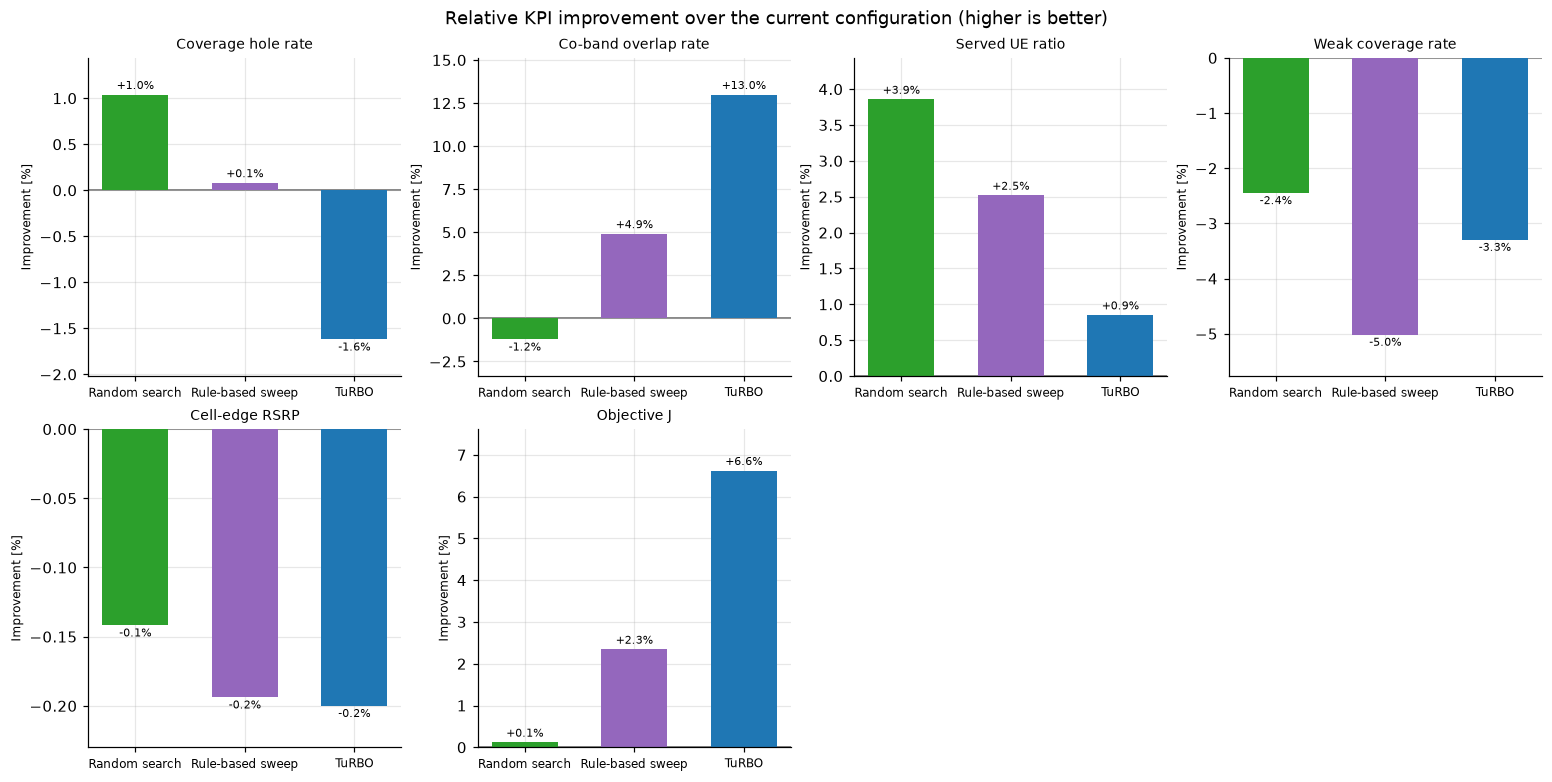

In [7]:
display(results["kpi_relative_improvement"])
display(results["kpi_improvement"])

**Observations.** No method improves every measure. TuRBO raises the objective most (+6.6 % relative, 0.591 to 0.630), almost entirely by cutting the co-band overlap rate by 13 % (0.369 to 0.321), with a small gain in served ratio (+0.9 %) and small losses in hole rate (−1.6 %), weak coverage (−3.3 %) and cell-edge RSRP (−0.2 dB). The rule-based sweep gains +2.3 % on J, with 4.9 % less overlap and 2.5 % more served UEs but 5.0 % more weak coverage. Random search gains only +0.1 % on J; it has the largest served-ratio gain (+3.9 %) and hole-rate gain (+1.0 %), but more overlap.

## 7. Optimization Convergence

Best objective found so far against the number of evaluations, the current configuration being evaluation 0. The
band is the min–max over seeds and collapses to the line with one seed.

The second table asks whether the search mattered: each winner against the typical candidate its own search evaluated.

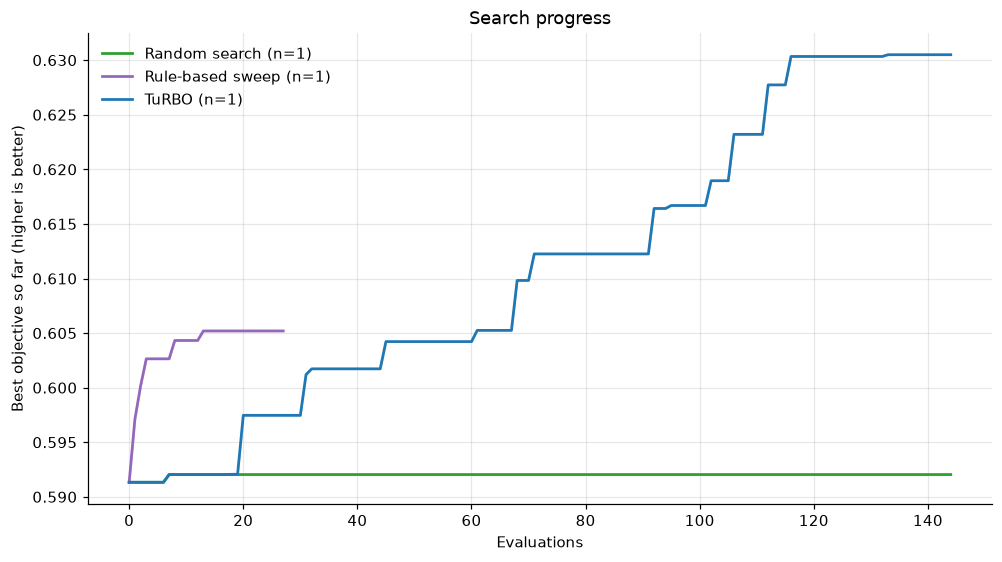

,Method,Seed,Current configuration,"Initial design, median objective","All candidates, median objective","All candidates, 90th percentile objective",Best objective found
0,Random search,42,0.5913,0.5641,0.5623,0.5758,0.5920
1,Rule-based sweep,42,0.5913,NaN,0.5985,0.6037,0.6052
2,TuRBO,42,0.5913,0.5641,0.6018,0.6232,0.6305


In [8]:
display(results["search_progress"])
display(results["winner_vs_candidates"])

**Observations.** The median candidate of TuRBO's search (0.602) already scores above random search's best (0.592), and its 90th percentile (0.623) above the sweep's best (0.605). The trust region spends its budget near good configurations, while random search's candidates stay close to its Sobol design median (0.564), below the current configuration. Random search found its best at evaluation index 7 and never improved after that. The rule-based sweep's median candidate (0.598) is high because it only moves whole bands around the current tilts.

## 8. Sample Efficiency

Best value reached after a fixed number of evaluations, averaged over seeds. Each KPI is its own running best, so the
rows of one budget need not come from one configuration. The last budget is the longest run; a budget past a run's
length is empty.

In [9]:
display(results["sample_efficiency"])

,KPI,Evaluations,Random search,Rule-based sweep,TuRBO
0,Objective J,10,0.5920,0.6043,0.5920
1,Objective J,25,0.5920,0.6052,0.5975
2,Objective J,50,0.5920,NaN,0.6042
3,Objective J,100,0.5920,NaN,0.6167
4,Objective J,145,0.5920,NaN,0.6305
5,Coverage hole rate,10,0.0725,0.0709,0.0725
6,Coverage hole rate,25,0.0725,0.0709,0.0724
7,Coverage hole rate,50,0.0721,NaN,0.0715
8,Coverage hole rate,100,0.0721,NaN,0.0715
9,Coverage hole rate,145,0.0721,NaN,0.0715


**Observations.** The rule-based sweep reaches J = 0.605 in 25 evaluations. TuRBO passes that after 61 evaluations (0.604 at 50, 0.617 at 100) and ends at 0.630 after 145. Random search stays at the value it reached within its first 10 evaluations. The running-best overlap rate falls steadily for TuRBO (0.369 to 0.321), while random search never finds a candidate with less overlap than the current configuration.

## 9. Stability and Statistical Comparison

TuRBO against random search, paired by seed because both share each seed's Sobol design: mean gain in objective, its
95 % t-interval and a Wilcoxon signed-rank test.

**Only one seed per method exists**, so no interval, spread or test can be computed. The rows below are the single
paired difference, not evidence of a consistent advantage. Repeating `task optim` over more seeds (e.g.
`task sweep -- seed=1,2,3`) would fill them.

In [10]:
display(results["paired_gain_turbo_vs_random"])

,Method,Reference,Seed pairs,Mean objective gain,95% CI lower,95% CI upper,Seeds won,Wilcoxon p-value
0,TuRBO,Random search,1,0.0385,NaN,NaN,1,NaN


## 10. Multi-Objective Trade-Offs and Pareto Fronts

Each point is one evaluated configuration. The stars mark each method's highest-$J$ configuration, the
cross marks the current configuration, and the dashed line joins the Pareto-efficient configurations over all methods:
those that no other configuration beats on both axes at once.

The served UE ratio takes the place of the template's band-priority axis, which is not used in this project.

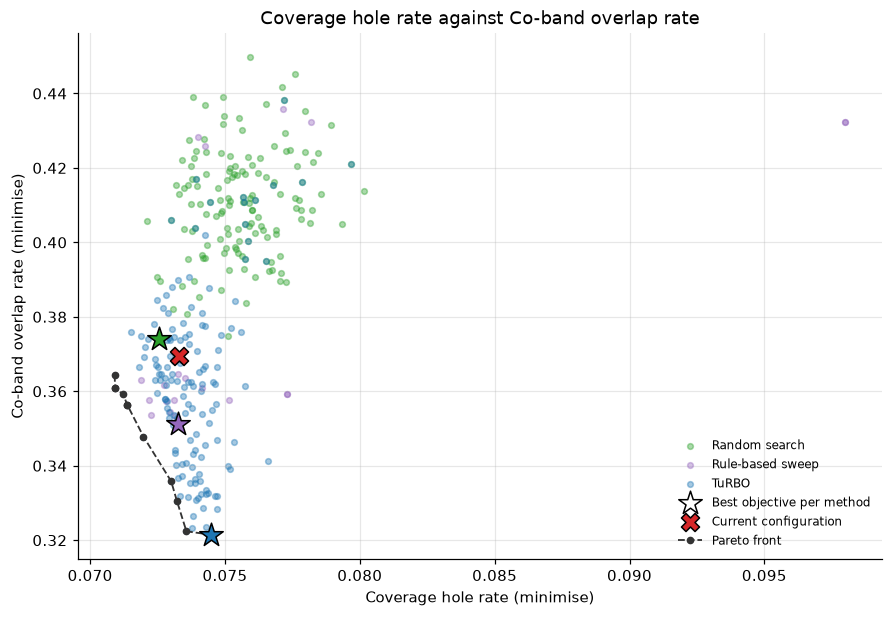

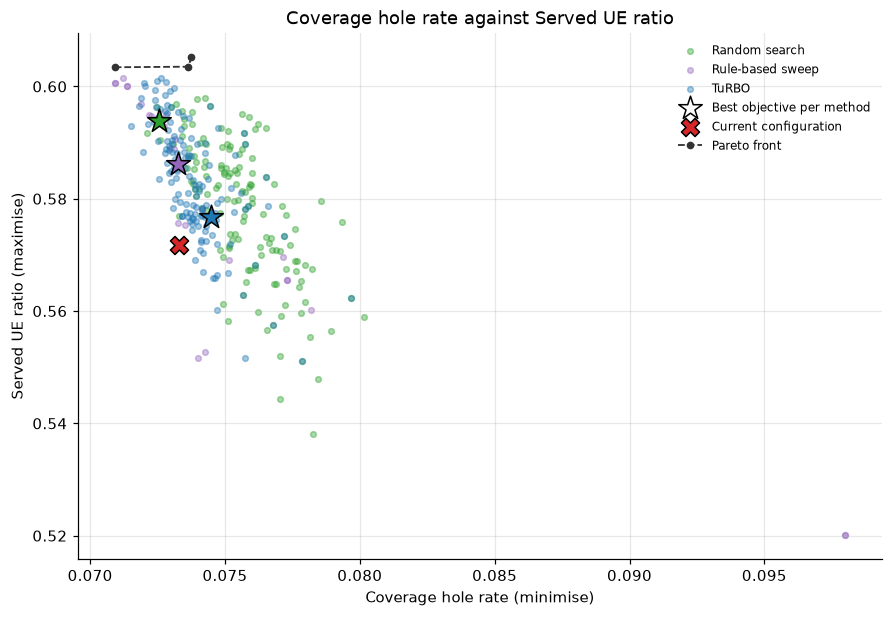

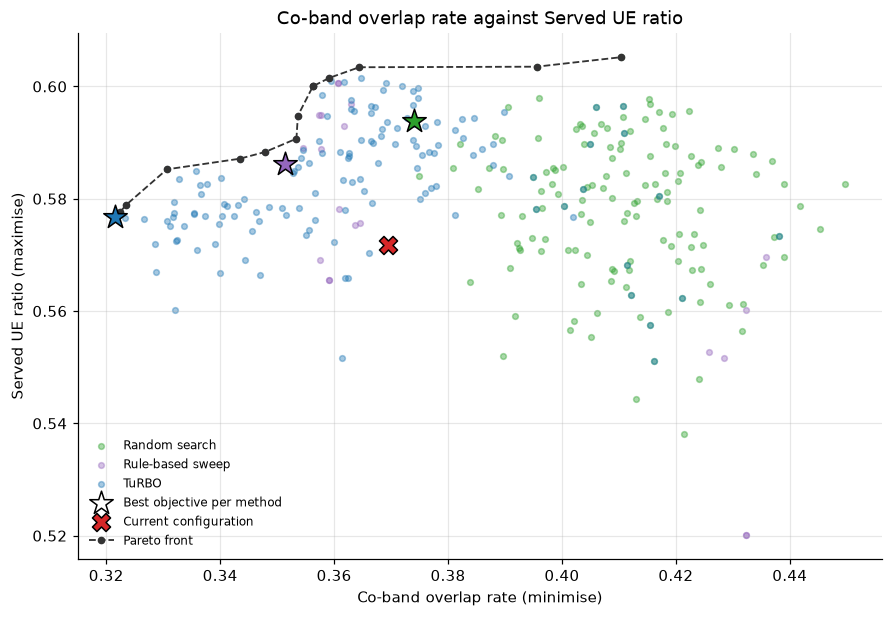

In [11]:
display(results["tradeoff_hole_rate_vs_overlap_rate"])
display(results["tradeoff_hole_rate_vs_served_ratio"])
display(results["tradeoff_overlap_rate_vs_served_ratio"])

**Observations.** Hole rate and overlap rate conflict: along the Pareto front, every step towards fewer holes costs overlap. The low-hole end of the front is made up of rule-sweep candidates (hole rate 0.071, overlap 0.356–0.364), and the low-overlap end of TuRBO's late candidates, ending in TuRBO's pick (hole rate 0.074, overlap 0.321). Random search's and the sweep's picks are dominated. Random search's candidates spread towards high overlap (up to 0.450).

## 11. Spatial Coverage Analysis

### 11.1 Change in best-server RSRP per method

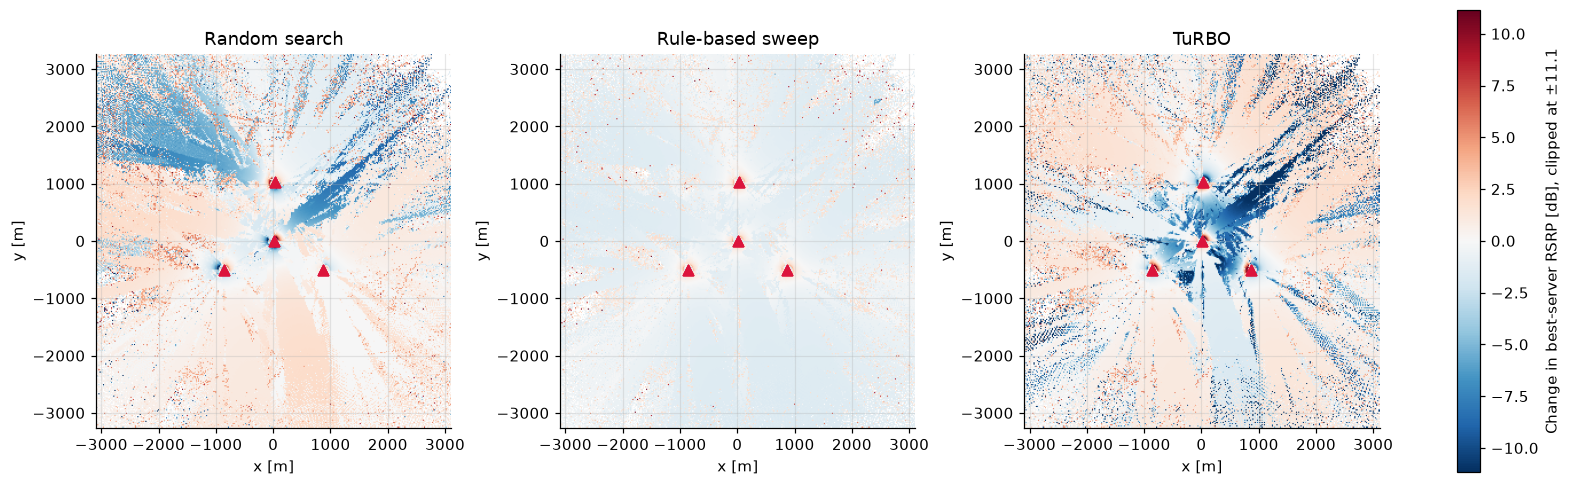

In [12]:
display(results["rsrp_change_maps"])

### 11.2 Before and after: the recommended configuration

The recommended configuration is the run with the highest objective over all methods. Both panels use the same scale
and the same coverage classes.

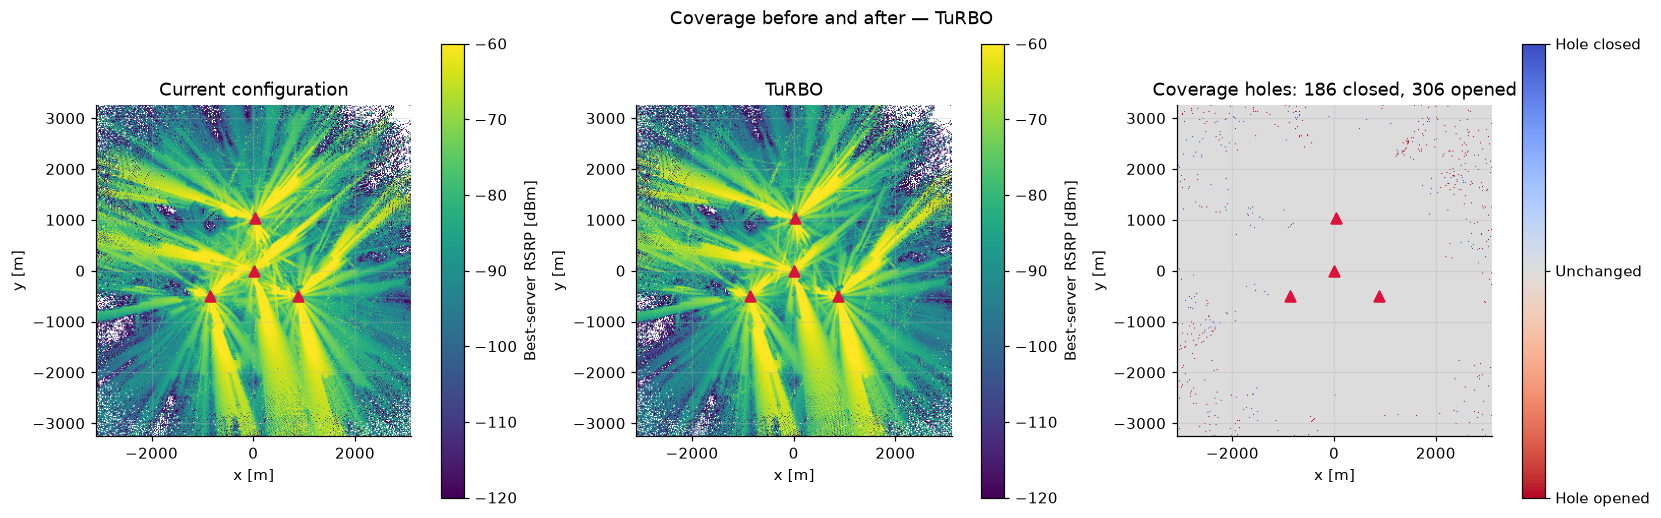

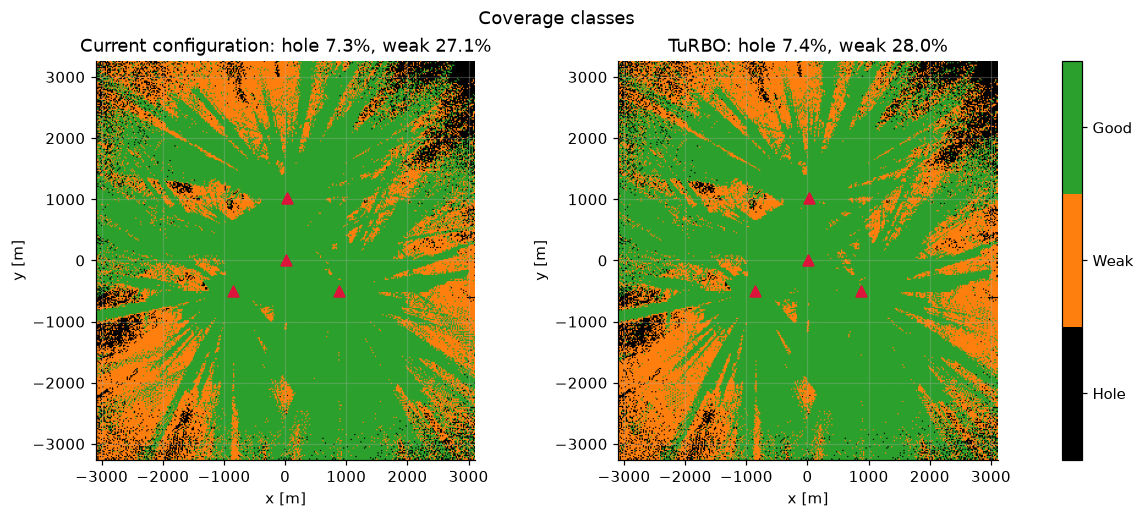

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.0733,0.0000,0.0725,0.0072,0.0732,0.0040,0.0745,0.0156
1,weak,0.2709,0.8099,0.2775,0.8055,0.2845,0.8301,0.2798,0.8119
2,good,0.6558,0.1901,0.6500,0.1873,0.6423,0.1658,0.6457,0.1724


In [13]:
display(results["coverage_before_after"])
display(results["coverage_class_maps"])
display(results["coverage_by_area_and_demand"])

### 11.3 Overlap neighbours

,Configuration,"Mean overlap neighbours, covered tiles","Mean overlap neighbours, all tiles",Share with 0 neighbours,Share with 1 neighbour,Share with 2 neighbours,Share with 3+ neighbours
0,Current configuration,1.1892,1.1020,0.6013,0.1135,0.0763,0.2089
1,Random search,1.2088,1.1211,0.5968,0.1300,0.0795,0.1938
2,Rule-based sweep,1.1065,1.0254,0.6209,0.1073,0.0672,0.2046
3,TuRBO,1.0533,0.9749,0.6527,0.1011,0.0629,0.1833


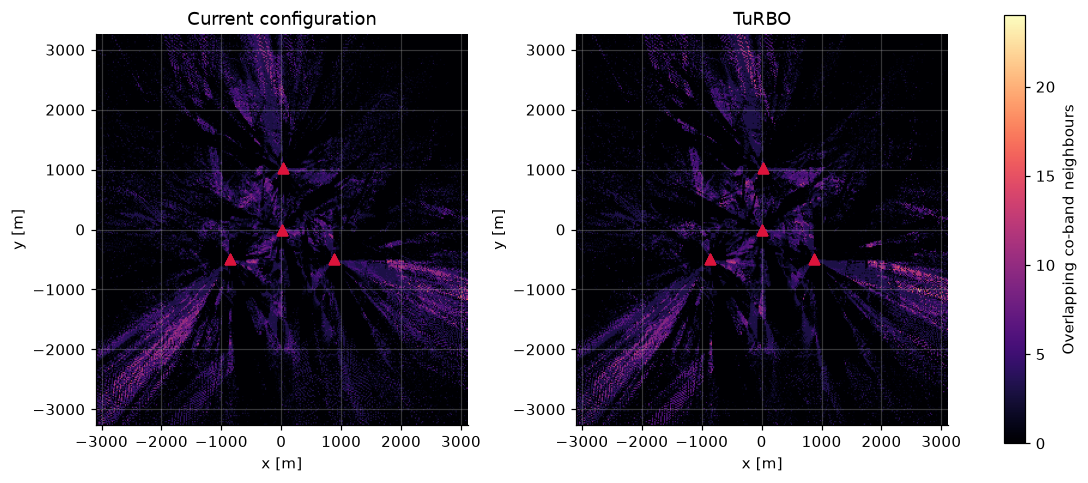

In [14]:
display(results["overlap_neighbour_summary"])
display(results["overlap_neighbour_maps"])

**Observations.** The recommended TuRBO configuration changes coverage classes only slightly: holes 7.3 % to 7.4 % of area, weak 27.1 % to 28.0 %. Weighted by demand, 1.6 % of demand moves onto hole tiles (none before), and the share on weak tiles stays at about 81 %. Overlap falls under TuRBO and the sweep: mean overlap neighbours over covered tiles go from 1.19 to 1.05 (TuRBO) and 1.11 (rule), and the share of tiles with three or more from 20.9 % to 18.3 % under TuRBO. Random search raises the mean to 1.21.

## 12. Frequency-Layer Analysis

Per band: the area the band covers above the hole threshold and its mean RSRP there, the area the serving rule assigns
to it, and the share of UE reports actually admitted on it after PRB limits, with their median SINR. The band preference
of the serving rule is `kpi.capacity.band_preference`.

,Configuration,Band,Share of area covered by the band,Mean band RSRP where covered [dBm],Share of area served on the band,Share of UE reports served on the band,"Served SINR on the band, median [dB]"
0,Current configuration,2600 MHz,0.7781,-96.7936,0.7781,0.3722,3.2936
1,Current configuration,1800 MHz,0.8287,-90.0190,0.0546,0.1106,4.1104
2,Current configuration,700 MHz,0.9086,-82.1247,0.0939,0.0890,12.3595
3,Random search,2600 MHz,0.8043,-91.6282,0.8043,0.4594,6.1065
4,Random search,1800 MHz,0.8329,-88.3173,0.0352,0.0617,4.2719
5,Random search,700 MHz,0.9079,-82.6190,0.0880,0.0728,11.6914
6,Rule-based sweep,2600 MHz,0.8024,-92.1587,0.8024,0.4612,5.3612
7,Rule-based sweep,1800 MHz,0.8325,-88.8213,0.0358,0.0537,3.0566
8,Rule-based sweep,700 MHz,0.9071,-83.0279,0.0886,0.0713,12.8482
9,TuRBO,2600 MHz,0.7967,-92.7504,0.7967,0.4194,5.1935


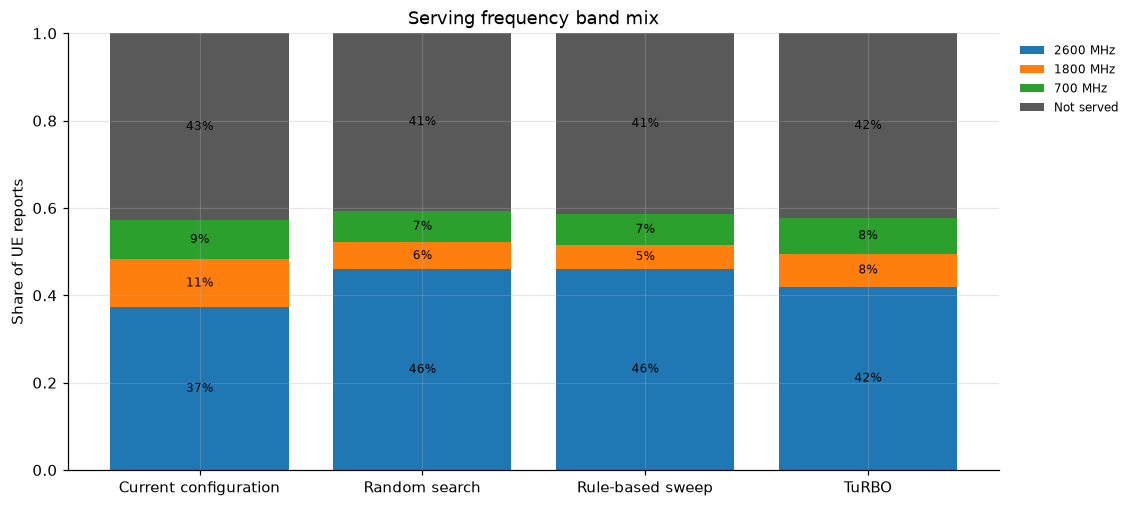

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10066.0,0.4282,-0.7549,4.5212,57.3283,0.3722,0.1106,0.0890
1,Random search,10066.0,0.4061,-0.3073,6.6999,44.3526,0.4594,0.0617,0.0728
2,Rule-based sweep,10066.0,0.4138,-0.5622,5.7317,49.4777,0.4612,0.0537,0.0713
3,TuRBO,10066.0,0.4233,-1.0007,5.9734,48.1124,0.4194,0.0759,0.0814


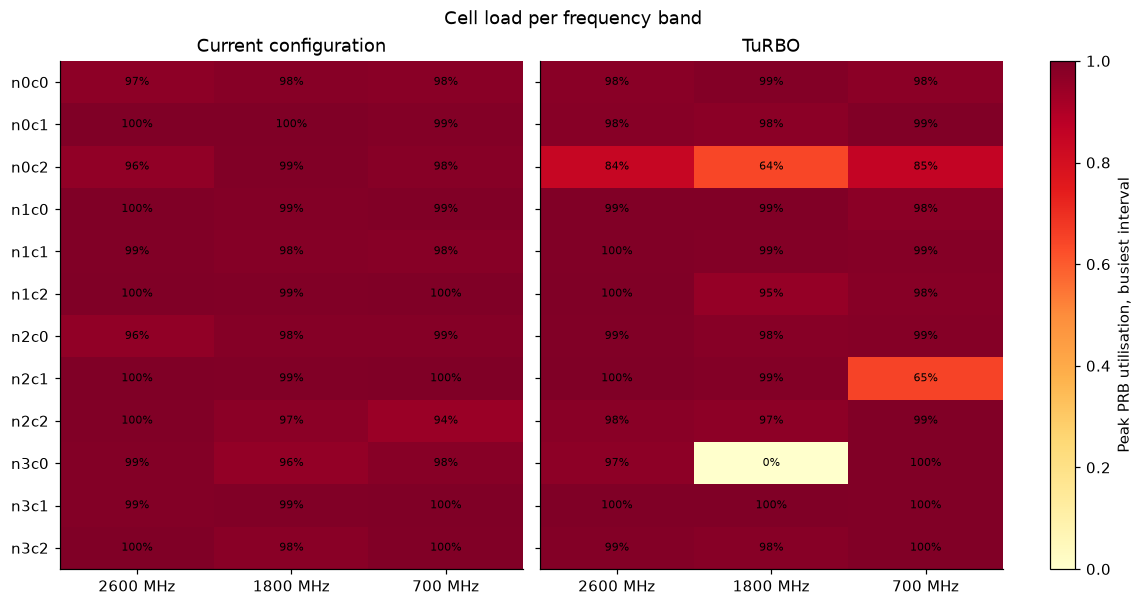

In [15]:
display(results["band_layer_summary"])
display(results["serving_band_mix"])
display(results["ue_service_summary"])
display(results["cell_band_utilisation"])

**Observations.** Area covered per band barely moves (within one point) under every method. Mean RSRP where covered rises on 2600 MHz (−96.8 to −92.8 dBm under TuRBO) and 1800 MHz (−90.0 to −88.6 dBm) and falls slightly on 700 MHz (−82.1 to −82.7 dBm). The share of UE reports served on 2600 MHz grows from 37 % to 42 % under TuRBO and 46 % under both baselines, while 1800 MHz falls from 11 % to 5–8 %, so the extra served UEs come from the preferred high band and part of the 1800 MHz traffic moves to it. The median served SINR on 700 MHz falls under TuRBO (12.4 to 10.9 dB). About 42 % of UE reports are still not served, which is the placeholder capacity model and the no-path hotspot, not the tilts; most cell-bands already run close to full PRB utilisation in the current configuration.

## 13. Tilt Configuration Analysis

$$
\Delta\theta_{i,b} = \theta^{*}_{i,b} - \theta^{(0)}_{i,b}
$$

for the recommended configuration. Negative is uptilt. The cell impact table is sorted by how much traffic each
cell-band gained or lost, so the cells to watch after rollout come first.

,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,1.0248,-10.9752,0.0,15.0
1,n0c0,1800 MHz,9.0,4.1844,-4.8156,0.0,15.0
2,n0c0,700 MHz,6.0,1.6346,-4.3654,0.0,15.0
3,n0c1,2600 MHz,12.0,3.7635,-8.2365,0.0,15.0
4,n0c1,1800 MHz,9.0,4.6275,-4.3725,0.0,15.0
5,n0c1,700 MHz,6.0,2.9406,-3.0594,0.0,15.0
6,n0c2,2600 MHz,12.0,14.6723,2.6723,0.0,15.0
7,n0c2,1800 MHz,9.0,14.7181,5.7181,0.0,15.0
8,n0c2,700 MHz,6.0,12.3488,6.3488,0.0,15.0
9,n1c0,2600 MHz,12.0,13.6575,1.6575,0.0,15.0


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,4.3330,6.8258,-1.6875
1,2600 MHz,12,12,4.8832,10.9752,-3.6245
2,700 MHz,12,12,3.9674,8.2888,1.1152


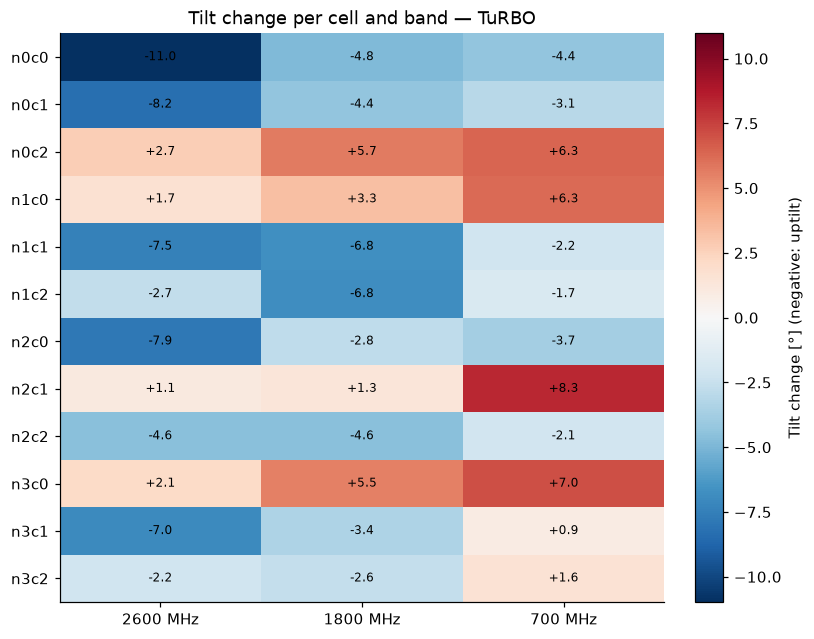

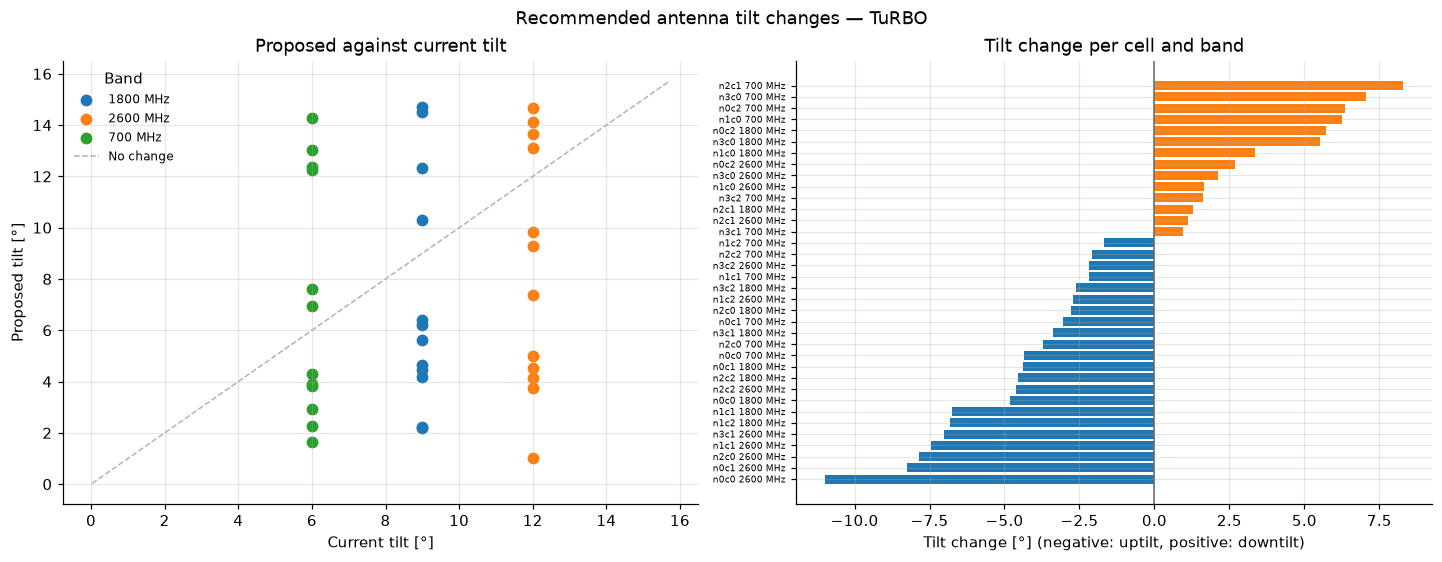

,Node,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n3,n3c1,165.0,2600 MHz,12.0,4.9861,-7.0139,220,0.9902,1.4780,550,0.9974,1.9011,330,7.2335e-03,0.4231
1,n2,n2c1,165.0,2600 MHz,12.0,13.1124,1.1124,621,0.9976,2.5728,370,0.9978,-0.0283,-251,2.0102e-04,-2.6011
2,n1,n1c1,165.0,2600 MHz,12.0,4.5468,-7.4532,483,0.9924,2.7566,681,0.9953,9.9846,198,2.8941e-03,7.2280
3,n1,n1c0,45.0,2600 MHz,12.0,13.6575,1.6575,412,0.9963,1.1462,279,0.9936,0.1526,-133,-2.6650e-03,-0.9937
4,n0,n0c1,165.0,2600 MHz,12.0,3.7635,-8.2365,295,0.9995,7.1222,413,0.9832,9.6251,118,-1.6292e-02,2.5029
5,n3,n3c2,285.0,2600 MHz,12.0,9.8223,-2.1777,726,0.9993,5.0858,837,0.9921,6.4061,111,-7.2026e-03,1.3203
6,n0,n0c2,285.0,2600 MHz,12.0,14.6723,2.6723,129,0.9612,0.0642,23,0.8414,8.6992,-106,-1.1981e-01,8.6350
7,n0,n0c0,45.0,2600 MHz,12.0,1.0248,-10.9752,151,0.9701,4.1905,242,0.9784,7.6031,91,8.2511e-03,3.4126
8,n1,n1c1,165.0,1800 MHz,9.0,2.2352,-6.7648,251,0.9850,6.7348,175,0.9894,5.1584,-76,4.4335e-03,-1.5764
9,n0,n0c1,165.0,1800 MHz,9.0,4.6275,-4.3725,139,0.9967,4.9703,70,0.9759,3.7216,-69,-2.0841e-02,-1.2486


In [16]:
display(results["recommended_tilt"])
display(results["tilt_movement_summary"])
display(results["tilt_delta_heatmap"])
display(results["tilt_movement"])
display(results["cell_impact"])

**Observations.** TuRBO uptilts 22 of 36 cell-bands and downtilts 14. Four cells (n0c2, n1c0, n2c1, n3c0) are downtilted on every band, five cell-bands to above 14°, close to the 15° upper bound, while n0c0 on 2600 MHz is uptilted to 1.0°, close to the 0° bound. On average per band, 2600 MHz moves −3.6°, 1800 MHz −1.7° and 700 MHz +1.1°. The largest traffic shifts are on 2600 MHz (top of the cell impact table: n3c1 +330 served reports, n2c1 −251, n1c1 +198), so those cells need watching after rollout.

## 14. Computational Cost

The expensive part is ray tracing, which is summed over every evaluation, apart from algorithm overhead (the difference
to wall clock: GP fitting and acquisition for TuRBO, I/O for all).

In [17]:
cost = results["method_cost"][["Method", "Seed", "Evaluations", "Ray tracing [min]", "Wall clock [min]"]].copy()
cost["Ray tracing per evaluation [s]"] = cost["Ray tracing [min]"] * 60 / cost["Evaluations"]
cost["Overhead [min]"] = cost["Wall clock [min]"] - cost["Ray tracing [min]"]
display(cost)

,Method,Seed,Evaluations,Ray tracing [min],Wall clock [min],Ray tracing per evaluation [s],Overhead [min]
0,Random search,42,145,7.5981,8.6798,3.1440,1.0817
1,Rule-based sweep,42,28,0.9097,1.1755,1.9494,0.2658
2,TuRBO,42,145,7.0320,10.7554,2.9098,3.7234


**Observations.** Ray tracing takes about 2–3 seconds per evaluation. On the same budget, TuRBO spent slightly less total ray-tracing time than random search (7.0 against 7.6 minutes); this run doesn't show why. TuRBO's GP fitting and acquisition overhead adds about 3.7 minutes to its wall clock (10.8 minutes in all). The rule sweep took 1.2 minutes but reached a lower objective.

## 15. Sensitivity Analysis

Not implemented: every parameter needs new ray-tracing runs, because the history stores only the measured objective.
That covers the initial design size, budget, trust-region settings, the thresholds $T_{\text{hole}}$ /
$\Delta_{\text{overlap}}$, $\tau_R$, $\beta$, the UE density model and tilt bounds.

## 16. Key Results

The recommended TuRBO winner against the current configuration and the best baseline (highest objective among random
search and the rule-based sweep), every UE. The improvement column is TuRBO relative to the current configuration,
positive is better.

In [18]:
board = results["kpi_scoreboard"]
means = board.pivot(index="KPI", columns="Method", values="Mean")
current = board.drop_duplicates("KPI").set_index("KPI")["Current configuration"]
baselines = [m for m in means.columns if m != "TuRBO"]
best_baseline = means.loc["Objective J", baselines].idxmax()
improvement = results["kpi_relative_improvement"].set_index("Method").loc["TuRBO"]
order = list(dict.fromkeys(board["KPI"]))
key_results = pd.DataFrame(
    {
        "Current configuration": current,
        f"Best baseline ({best_baseline})": means[best_baseline],
        "TuRBO": means["TuRBO"],
        "TuRBO improvement [%]": improvement,
    }
).loc[order]
display(key_results)

,Current configuration,Best baseline (Rule-based sweep),TuRBO,TuRBO improvement [%]
Coverage hole rate,0.0733,0.0732,0.0745,-1.6199
Co-band overlap rate,0.3695,0.3513,0.3215,12.9921
Served UE ratio,0.5718,0.5862,0.5767,0.8513
Weak coverage rate,0.2709,0.2845,0.2798,-3.2950
Cell-edge RSRP,-105.6556,-105.8603,-105.8668,-0.2000
Objective J,0.5913,0.6052,0.6305,6.6227


### Main observations

* **Coverage:** TuRBO slightly worsens coverage by area: hole rate +1.6 % and weak-coverage rate +3.3 % relative to the current configuration, and cell-edge RSRP −0.2 dB.
* **Overlap:** the co-band overlap rate falls by 13 % relative (0.369 to 0.321), mean overlap neighbours fall from 1.19 to 1.05, and pile-ups of three or more neighbours fall. This is where TuRBO's gain in J comes from.
* **Band coordination:** served UEs rise slightly; the 2600 MHz share grows (37 % to 42 % of reports) and 1800 MHz shrinks.
* **Optimization efficiency:** TuRBO passes the rule-based sweep's best after 61 evaluations and ends 0.025 above it at 145. Random search stalls within 10.
* **Robustness:** unknown, since only one seed per method exists.

## 17. Figures for Presentation

All saved under `reports/figures/04_evaluation/`.

| # | Figure | File | Purpose |
|---|---|---|---|
| 1 | Overall KPI comparison | `kpi_improvement.png` | Direct comparison of every method's improvement |
| 2 | Optimization convergence | `search_progress.png` | Sample efficiency of the search |
| 3 | Hole–overlap trade-off | `tradeoff_hole_rate_vs_overlap_rate.png` | Coverage against overlap, with the Pareto front |
| 4 | Coverage before vs after | `coverage_before_after.png`, `coverage_class_maps.png` | Where coverage changed |
| 5 | Serving band distribution | `serving_band_mix.png` | Whether multi-band coordination behaves as intended |
| 6 | Tilt adjustment heatmap | `tilt_delta_heatmap.png` | What the optimizer decided |

## 18. Conclusions

1. **Holes:** no. TuRBO and the sweep leave the hole rate practically unchanged (TuRBO +1.6 % relative); random search lowers it by 1 %.
2. **Co-band overlap:** yes for TuRBO (−13 % relative) and the sweep (−4.9 %); random search raises it.
3. **Overlapping neighbours:** the mean per covered tile and the share of tiles with three or more fall under TuRBO and the sweep.
4. **Frequency layers:** the extra served UEs land on the preferred 2600 MHz layer, and part of the 1800 MHz traffic moves there too.
5. **Consistency across runs:** not measurable yet, with one seed per method.
6. **Evaluations needed:** the rule sweep reaches its result in 25 evaluations; TuRBO passes it after 61.
7. **Tilt changes:** mixed. TuRBO uptilts most cell-bands and downtilts four cells on every band, some close to the 15° bound.
8. **Remaining trade-off:** overlap against coverage. The objective's overlap penalty outweighs the small losses in hole and weak coverage.

**Final summary.** TuRBO achieved a 6.6 % higher objective than the current configuration, with 13 % less co-band overlap and 0.9 % more served UEs, at the cost of 1.6 % more holes, 3.3 % more weak coverage and 0.2 dB lower cell-edge RSRP. The rule-based sweep reached +2.3 % in 28 evaluations and random search +0.1 %. On this scenario and single seed TuRBO is ahead of both baselines on the objective, but multi-seed runs are needed before recommending it.

### Threats to validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | — | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | — | Open: re-tracing under other solver seeds is not implemented |
| 3 | Simple reference: the current configuration uses one tilt per band for every cell | Section 7, winner against candidates | Reported |
| 4 | One search seed per method: no spread, interval or test | Section 9 | Open |
| 5 | The objective depends on judgement parameters (tau_R, beta) | Section 15 | Open: no sensitivity analysis |
| 6 | Hole and weak rates count area, including area without users | Section 11.2, coverage by area and by demand | Reported |
| 7 | The served ratio relies on placeholder capacity settings | `configs/kpi.yaml` `capacity` | Open |
| 9 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements | Notebook 01, data quality | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement is not constrained | Sections 8, 13, 14 | Reported |
| 11 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | — | Open |

## Appendix — Reproducibility

In [19]:
import platform
from importlib.metadata import version

from omegaconf import OmegaConf

setup = results["experiment_setup"].set_index("Parameter")["Setting"]
commit = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
dirty = bool(subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip())
record = {
    "Scenario": setup["Scenario"],
    "Code commit": f"{commit}{' (uncommitted changes)' if dirty else ''}",
    "Runs": ", ".join(f"{m}/{r}" for m, r in results["method_cost"][["Method", "Run"]].itertuples(index=False)),
    "Search seeds": sorted(results["method_cost"]["Seed"].unique().tolist()),
    "Global seed": cfg.seed,
    "Tilt bounds [°]": setup["Tilt bounds [°]"],
    "Tilt step / maximum change": "none (continuous, unconstrained change)",
    "KPI thresholds": OmegaConf.to_container(cfg.kpi, resolve=True),
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    **{name: version(name) for name in ("numpy", "pandas", "scipy", "matplotlib", "hydra-core")},
}
for key, value in record.items():
    print(f"{key}: {value}")

Scenario: scn_7d938e15f9ac4618
Code commit: e97b50d1c6476ee3cc41d139d9e150b2aa76926c (uncommitted changes)
Runs: Random search/2026-09-17_13-46-51, Rule-based sweep/2026-09-17_13-55-32, TuRBO/2026-09-17_13-57-03
Search seeds: [42]
Global seed: 42
Tilt bounds [°]: 0 to 15
Tilt step / maximum change: none (continuous, unconstrained change)
KPI thresholds: {'hole_dbm': -120.0, 'weak_dbm': -90.0, 'overlap_margin_db': 6.0, 'objective': {'tau_r_db': 10.0, 'beta': 1.0}, 'quality': {'edge_percentile': 5.0}, 'capacity': {'band_preference': ['b2600', 'b1800', 'b700'], 'rsrp_threshold_dbm': -120.0, 'max_admission_utilisation': 0.8, 'throughput_per_ue_bps': 20000000, 'bands': {'b2600': {'scs_hz': 15000}, 'b1800': {'scs_hz': 15000}, 'b700': {'scs_hz': 15000}}}}
Python: 3.13.14
Platform: Windows-11-10.0.26200-SP0
numpy: 2.5.2
pandas: 2.3.3
scipy: 1.18.1
matplotlib: 3.11.1
hydra-core: 1.3.6
